# 06.15_SAMap_9_species_analysis_Python

九物种 SAMap 映射与可视化。

- 当前文件：`analysis/06_single_cell_analysis/06.15_SAMap_9_species_analysis_Python.ipynb`
- 原始来源：`Codes/06.12_SAMap_9_species_analysis.ipynb`（旧编号仅用于溯源）。
- 运行内核：**python**。
- 导入依赖：`holoviews`, `json`, `matplotlib.pyplot`, `numpy`, `pandas`, `pickle`, `plotly.graph_objects`, `samalg`, `samap.analysis`, `samap.mapping`, `scanpy`, `scipy`, `scipy.sparse`, `seaborn`。
- 当前编号与流程见 `docs/workflow.md`、`docs/code_index.md`。
- 仅更新整理版导读；原分析单元格、参数和顺序保持不变。原始 cell 索引在本文件中加 1。


In [ ]:
fig_dir = '/share/home/zhangze/zz/NeuralOrigin/Figures'

# Import Packages

In [ ]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd

# Running BLAST

# Running SAMap

## Loading in raw data

In [ ]:
fn1 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/Dare.normalized.h5ad'
fn2 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/Neve.normalized.h5ad'
fn3 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/Auco.normalized.annotated.h5ad'
fn4 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/Clhe.normalized.h5ad'
fn5 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/TrH1.normalized.h5ad'
fn6 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/TrH2.normalized.h5ad'
fn7 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/HoH13.normalized.h5ad'
fn8 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/ClH23.normalized.h5ad'
fn9 = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_input/h5ad/Spla.normalized.h5ad'

In [ ]:
import scanpy as sc

adata_1 = sc.read_h5ad(fn1)
adata_2 = sc.read_h5ad(fn2)
adata_3 = sc.read_h5ad(fn3)
adata_4 = sc.read_h5ad(fn4)
adata_5 = sc.read_h5ad(fn5)
adata_6 = sc.read_h5ad(fn6)
adata_7 = sc.read_h5ad(fn7)
adata_8 = sc.read_h5ad(fn8)
adata_9 = sc.read_h5ad(fn9)

print(adata_1)
print(adata_2)
print(adata_3)
print(adata_4)
print(adata_5)
print(adata_6)
print(adata_7)
print(adata_8)
print(adata_9)

SAMap expects the above to be in a dictionary keyed by the species IDs determined in the BLAST step:

In [ ]:
# 检查数据格式

from scipy.sparse import csr_matrix

print(type(adata_1.X))
print(type(adata_2.X))
print(type(adata_3.X))
print(type(adata_4.X))
print(type(adata_5.X))
print(type(adata_6.X))
print(type(adata_7.X))
print(type(adata_8.X))
print(type(adata_9.X))

# 如果不是 csr_matrix，建议转换：
if not isinstance(adata_1.X, csr_matrix):
    print('adata_1 不是 csr_matrix')
    adata_1.X = csr_matrix(adata_1.X)
if not isinstance(adata_2.X, csr_matrix):
    print('adata_2 不是 csr_matrix')
    adata_2.X = csr_matrix(adata_2.X)
if not isinstance(adata_3.X, csr_matrix):
    print('adata_3 不是 csr_matrix')
    adata_3.X = csr_matrix(adata_3.X)
if not isinstance(adata_4.X, csr_matrix):
    print('adata_4 不是 csr_matrix')
    adata_4.X = csr_matrix(adata_4.X)
if not isinstance(adata_5.X, csr_matrix):
    print('adata_5 不是 csr_matrix')
    adata_5.X = csr_matrix(adata_5.X)
if not isinstance(adata_6.X, csr_matrix):
    print('adata_6 不是 csr_matrix')
    adata_6.X = csr_matrix(adata_6.X)
if not isinstance(adata_7.X, csr_matrix):
    print('adata_7 不是 csr_matrix')
    adata_7.X = csr_matrix(adata_7.X)
if not isinstance(adata_8.X, csr_matrix):
    print('adata_8 不是 csr_matrix')
    adata_8.X = csr_matrix(adata_8.X)
if not isinstance(adata_9.X, csr_matrix):
    print('adata_9 不是 csr_matrix')
    adata_9.X = csr_matrix(adata_9.X)

print(type(adata_1.X))
print(type(adata_2.X))
print(type(adata_3.X))
print(type(adata_4.X))
print(type(adata_5.X))
print(type(adata_6.X))
print(type(adata_7.X))
print(type(adata_8.X))
print(type(adata_9.X))

In [ ]:
import numpy as np

# 如果是稀疏矩阵，先拿出数据部分
print("Min:", np.min(adata_1.X.data), "Max:", np.max(adata_1.X.data))
print("Percentiles:", np.percentile(adata_1.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_2.X.data), "Max:", np.max(adata_2.X.data))
print("Percentiles:", np.percentile(adata_2.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_3.X.data), "Max:", np.max(adata_3.X.data))
print("Percentiles:", np.percentile(adata_3.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_4.X.data), "Max:", np.max(adata_4.X.data))
print("Percentiles:", np.percentile(adata_4.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_5.X.data), "Max:", np.max(adata_5.X.data))
print("Percentiles:", np.percentile(adata_5.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_6.X.data), "Max:", np.max(adata_6.X.data))
print("Percentiles:", np.percentile(adata_6.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_7.X.data), "Max:", np.max(adata_7.X.data))
print("Percentiles:", np.percentile(adata_7.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_8.X.data), "Max:", np.max(adata_8.X.data))
print("Percentiles:", np.percentile(adata_8.X.data, [0, 25, 50, 75, 100]))

print("Min:", np.min(adata_9.X.data), "Max:", np.max(adata_9.X.data))
print("Percentiles:", np.percentile(adata_9.X.data, [0, 25, 50, 75, 100]))

In [ ]:
filenames = {
    'Dare': fn1,
    'Neve': fn2,
    'Auco': fn3,
    'Clhe': fn4,
    'TrH1': fn5,
    'TrH2': fn6,
    'HoH13': fn7,
    'ClH23': fn8,
    'Spla': fn9
}

In [ ]:
keys = {
    'Dare': 'broad_cell_type',
    'Neve': 'CellType',
    'Auco': 'Broad_cell_type',
    'Clhe': 'annos',
    'TrH1': 'broad_cell_type',
    'TrH2': 'broad_cell_type',
    'HoH13': 'broad_cell_type',
    'ClH23': 'broad_cell_type',
    'Spla': 'CellTypeFamily'
}

sm = SAMAP(
    filenames,
    f_maps = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/maps/',
    save_processed=True,
    keys=keys   # 新增这一行，指定各自聚类/注释
)

In [ ]:
import pickle

sm.run(pairwise=True)
samap = sm.samap # SAM object with three species stitched together
print(sm)
print(samap)

# 保存sm
sm_pickle_path = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/sm_9_species.pkl'
with open(sm_pickle_path, 'wb') as f:
    pickle.dump(sm, f)

In [ ]:
import pickle

sm_pickle_path = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/sm_9_species.pkl'

# 读取 pickle 文件
with open(sm_pickle_path, 'rb') as f:
    sm = pickle.load(f)

# 检查读取的对象
print(sm)
print(sm.sams)

### Digression: How does SAMap robustly determine cross-species neighbors?

SAMap initially identifies the k-nearest cross-species neighbors for each cell. It then looks at the mutual connectivity between neighborhoods of cells rather than individual cells to determine the connectivity of cells across species (see panel **D** below):

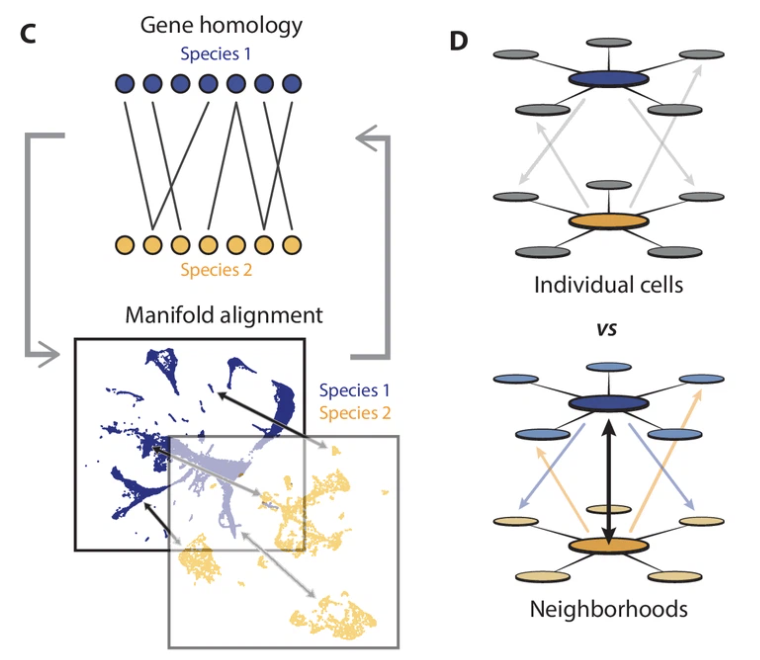

In this way, even if two cells are NOT directly connected to each other in the initial kNN graph, if their ***neighborhoods*** are connected, then these two cells will be considered as neighboring regardless. The exact edge weight is calculated by looking at the fraction of edges connecting their two neighborhoods.

By default, SAMap identifies neighborhoods within species by hopping along the outgoing edges from each cell in each species' manifold (constructed by SAM). To ensure that the neighborhoods do not get unreasonably large, this "hopping" is truncated by the size of the cluster to which each cell belongs. In other words, each cell's neighborhood will never be bigger than the size of its cluster. In this way, we mitigate scenarios where the neighborhoods of distinct cell types are erroneously merged together.

The clusters are computed using leiden clustering, and the resolution parameter is set to 3 by default. The resolution parameter can be specified using the `resolutions` argument in `SAMAP` as follows:

# Post-SAMap analysis

Okay, so we were able to produce a SAM object, `samap = sm.samap`, with all three species stitched together.

Some notes about the combined SAM object:
- The expression data in `samap.adata` is a block-diagonal matrix of each species' gene expressions.
- The species ID for each cell is stored in `samap.adata.obs['species']`
- The combined graph is stored in `samap.adata.obsp['connectivities']`
- The refined homology graph is stored in `samap.adata.varp['homology_graph_reweighted']` (or `sm.gnnm_refined`) and the gene names corresponding to this graph are stored in `samap.adata.var_names` (or `sm.gns`).

Now, I'll go over some tools I provide to help interpret and visualize your results.


## Querying gene mapping scores

To get the gene-gene mapping scores (both BLAST and correlation scores), we can use `SAMAP.query_gene_pairs` or `SAMAP.query_gene_pair`. The latter accepts one gene, and returns scores to all its neighbors in the BLAST and correlation homology graphs. The former accepts two genes and returns the edge weight between them.

In [ ]:
sm.query_gene_pairs('XLOC-019965#SYT14-HUMAN#Q8NB59')

In [ ]:
sm.query_gene_pair('XLOC-019965#SYT14-HUMAN#Q8NB59','Clhe_XLOC-000865')

## Calculating cell type mapping scores

To calculate alignment scores between cell types, we can use `get_mapping_scores`. This function will use the combined SAM object produced by SAMap to calculate alignment scores between cell types in the provided cell type annotation columns of `sam.adata.obs`. If no cell type annotations exist, the leiden clusters generated by SAM can be used (`'leiden_clusters'`).

The resulting tables show the highest-scoring alignment scores for each cell type (`D`) and pairwise mapping scores between cell types (`MappingTable`).

In [ ]:
keys = {
    'Dare': 'broad_cell_type',
    'Neve': 'CellType',
    'Auco': 'Broad_cell_type',
    'Clhe': 'annos',
    'TrH1': 'broad_cell_type',
    'TrH2': 'broad_cell_type',
    'HoH13': 'broad_cell_type',
    'ClH23': 'broad_cell_type',
    'Spla': 'CellTypeFamily'
}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)

In [ ]:
D.head()

In [ ]:
MappingTable.head()

The `n_top` parameter can be used to identify strongly-mapping subpopulations between clusters. If `n_top=0`, the alignment score will be averaged over all cells between two clusters. Otherwise, the alignment score will be averaged over the top `n_top` cells.

For example, let's say there are 100 / 1000 cells in Cluster A that maps to a Cluster B in the other species. On average, the mapping score between cluster A and B will be small, because there are only a few cells in cluster A that map to cluster B. If we set `n_top` to 100, then the alignment score between A and B will be averaged over the 100 highest-scoring cells. As a result, the mapping score between A and B will be large.

By default, `n_top=0`.

In [ ]:
D.to_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/mapping_score_D.csv")
MappingTable.to_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/mapping_score_MappingTable.csv")

In [ ]:
import pandas as pd

D = pd.read_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/mapping_score_D.csv", index_col='Unnamed: 0')
MappingTable = pd.read_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/mapping_score_MappingTable.csv", index_col='Unnamed: 0')
MappingTable

## Visualizing mapping scores

We can display a sankey plot to visualize mapping scores. Since the sankey plot is inherently a 2D visualization tool, we can only use it to visualize a linear set of connections. For example, in the first diagram below, the connections between planarian and hydra cell types are not shown.

- The linear species ordering can be specified by using `species_order`.
- `align_thr=0.05` zeros out mappings with alignment scores less than 0.05

In [ ]:
import pandas as pd
import scipy as sp
import numpy as np
# import samalg.utilities as ut
# import warnings
import scanpy as sc
# __version__ = "1.0.15"

def q(x):
    return np.array(list(x))

def sankey_plot_zz(M,species_order=None,align_thr=0.1,**params):
    """Generate a sankey plot
    
    Parameters
    ----------
    M: pandas.DataFrame
        Mapping table output from `get_mapping_scores` (second output).

    align_thr: float, optional, default 0.1
        The alignment score threshold below which to remove cell type mappings.
    
    species_order: list, optional, default None
        Specify the order of species (left-to-right) in the sankey plot.
        For example, `species_order=['hu','le','ms']`.

    Keyword arguments
    -----------------
    Keyword arguments will be passed to `sankey.opts`.
    """    
    if species_order is not None:
        ids = np.array(species_order)
    else:
        ids = np.unique([x.split('_')[0] for x in M.index])

    if len(ids)>2:
        d = M.values.copy()
        d[d<align_thr]=0
        x,y = d.nonzero()
        x,y = np.unique(np.sort(np.vstack((x,y)).T,axis=1),axis=0).T
        values = d[x,y]
        nodes = q(M.index)

        node_pairs = nodes[np.vstack((x,y)).T]
        sn1 = q([xi.split('_')[0] for xi in node_pairs[:,0]])
        sn2 = q([xi.split('_')[0] for xi in node_pairs[:,1]])
        # filt = np.logical_or(
        #     np.logical_or(np.logical_and(sn1==ids[0],sn2==ids[1]),np.logical_and(sn1==ids[1],sn2==ids[0])),
        #     np.logical_or(np.logical_and(sn1==ids[1],sn2==ids[2]),np.logical_and(sn1==ids[2],sn2==ids[1]))
        # )
        # x,y,values=x[filt],y[filt],values[filt]
        # d=dict(zip(ids,list(np.arange(len(ids)))))        
        
        # ZZ 模改
        # 模改一：保证多物种绘制
        d = dict(zip(ids, np.arange(len(ids))))
        sidx1 = np.array([d[s] for s in sn1])
        sidx2 = np.array([d[s] for s in sn2])
        # 只保留相邻物种之间的连边（如果想全保留可以直接注释掉这一行）
        filt = np.abs(sidx1 - sidx2) == 1
        x, y, values = x[filt], y[filt], values[filt]


        depth_map = dict(zip(nodes,[d[xi.split('_')[0]] for xi in nodes]))
        data =  nodes[np.vstack((x,y))].T
        for i in range(data.shape[0]):
            if d[data[i,0].split('_')[0]] > d[data[i,1].split('_')[0]]:
                data[i,:]=data[i,::-1]
        R = pd.DataFrame(data = data,columns=['source','target'])
        R['depth'] = R['source'].apply(lambda x: d[x.split('_')[0]])    # 为每个节点明确标注 depth（列索引）
        R['Value'] = values
        print(R['depth'])
        print(R['Value'])
               
    else:
        d = M.values.copy()
        d[d<align_thr]=0
        x,y = d.nonzero()
        x,y = np.unique(np.sort(np.vstack((x,y)).T,axis=1),axis=0).T
        values = d[x,y]
        nodes = q(M.index)
        R = pd.DataFrame(data = nodes[np.vstack((x,y))].T,columns=['source','target'])
        R['Value'] = values
        depth_map=None
    
    try:
        from holoviews import dim
        #from bokeh.models import Label
        import holoviews as hv
        hv.extension('bokeh',logo=False)
        hv.output(size=100)        
    except:
        raise ImportError('Please install holoviews-samap with `!pip install holoviews-samap`.')

    def f(plot,element):
        plot.handles['plot'].sizing_mode='scale_width'    
        plot.handles['plot'].x_range.start = -600    
        #plot.handles['plot'].add_layout(Label(x=plot.handles['plot'].x_range.end*0.78, y=plot.handles['plot'].y_range.end*0.96, text=id2))
        plot.handles['plot'].x_range.end = 1500    
        #plot.handles['plot'].add_layout(Label(x=0, y=plot.handles['plot'].y_range.end*0.96, text=id1))


    # sankey1 = hv.Sankey(R, kdims=["source", "target"])#, vdims=["Value"])
    sankey1 = hv.Sankey(
        R, 
        kdims=["source", "target"],
        vdims=["Value", "depth"])

    cmap = params.get('cmap','Colorblind')
    label_position = params.get('label_position','outer')
    edge_line_width = params.get('edge_line_width',0)
    show_values = params.get('show_values',False)
    node_padding = params.get('node_padding',6)
    node_alpha = params.get('node_alpha',1.0)
    node_width = params.get('node_width',10)
    node_sort = params.get('node_sort',False)
    frame_height = params.get('frame_height',1200)
    frame_width = params.get('frame_width',2400)
    bgcolor = params.get('bgcolor','snow')
    apply_ranges = params.get('apply_ranges',True)


    sankey1.opts(cmap=cmap,label_position=label_position, edge_line_width=edge_line_width, show_values=show_values,
                 node_padding=node_padding,node_cmap=depth_map, node_alpha=node_alpha, node_width=node_width,
                 node_sort=node_sort,frame_height=frame_height,frame_width=frame_width,bgcolor=bgcolor,
                 apply_ranges=apply_ranges,hooks=[f])

    return sankey1

In [ ]:
import holoviews as hv
hv.extension('bokeh')

sankey_obj = sankey_plot_zz(MappingTable, align_thr=0, species_order = ['Spla', 'ClH23', 'HoH13', 'TrH2', 'TrH1', 'Clhe', 'Auco', 'Neve', 'Dare'])
# 可选：直接notebook中查看，通常会没效果
sankey_obj
sankey_obj.opts(frame_width=2400, frame_height=1000)
hv.save(sankey_obj, "/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/sankey_plot_9_species.html", resources='inline')

In [ ]:
df = MappingTable.copy()

# 获取所有细胞类型的行名和列名
row_celltypes = df.index.tolist()      # 行名全是字符串
col_celltypes = df.columns.tolist()    # 列名全是字符串

# 过滤出物种前缀
rows = [r for r in row_celltypes if r.startswith("Spla_")]
cols = [c for c in col_celltypes if c.startswith("ClH23_")]

# 截取子矩阵
submatrix = df.loc[rows, cols]
submatrix.head()

In [ ]:
row_celltypes

In [ ]:
import pandas as pd

# Step 1: 对每一列，在行中找最大值（即 ClH23 每个细胞类型最匹配的 Spla 类型）
edges = []
for col in submatrix.columns:
    best_row = submatrix[col].idxmax()
    best_score = submatrix[col].max()
    if best_score > 0:
        edges.append({
            'source': best_row,
            'target': col,
            'value': best_score
        })

# 创建唯一节点索引
nodes = pd.unique([e['source'] for e in edges] + [e['target'] for e in edges])
node_to_index = {name: i for i, name in enumerate(nodes)}

# 构建 Sankey 数据
sankey_sources = [node_to_index[e['source']] for e in edges]
sankey_targets = [node_to_index[e['target']] for e in edges]
sankey_values = [e['value'] for e in edges]

# 绘图
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=list(nodes),
        color=["#1f77b4" if n.startswith("Spla_") else "#ff7f0e" for n in nodes]
    ),
    link=dict(
        source=sankey_sources,
        target=sankey_targets,
        value=sankey_values,
        color="lightgray"
    ))])

fig.update_layout(title_text="ClH23 ← Spla 细胞类型最大映射图", font_size=12)
# fig.show()
fig.write_html("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/spla_clh13_sankey.html")


In [ ]:
# Step 1: 所有节点
all_nodes = sorted(set(rows) | set(cols))
node_to_index = {name: i for i, name in enumerate(all_nodes)}

# Step 2: 构建真实连线
edges = []
for col in submatrix.columns:
    best_row = submatrix[col].idxmax()
    best_score = submatrix[col].max()
    if best_score > 0:
        edges.append({
            'source': best_row,
            'target': col,
            'value': best_score
        })

# Step 3: 添加自环以保证无连边节点出现
linked_nodes = set([e['source'] for e in edges] + [e['target'] for e in edges])
unlinked_nodes = set(all_nodes) - linked_nodes
for node in unlinked_nodes:
    edges.append({
        'source': node,
        'target': node,
        'value': 1e-5  # 非零但极小，避免图形错误
    })

# ⭐️ 关键：在添加自环后重新生成 sankey_sources/targets/values
sankey_sources = [node_to_index[e['source']] for e in edges]
sankey_targets = [node_to_index[e['target']] for e in edges]
sankey_values = [e['value'] for e in edges]

# Step 4: 绘图
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=["#1f77b4" if n.startswith("Spla_") else "#ff7f0e" for n in all_nodes]
    ),
    link=dict(
        source=sankey_sources,
        target=sankey_targets,
        value=sankey_values,
        color="lightgray"
    ))])

fig.update_layout(title_text="完整节点显示的 Spla → ClH23 映射图", font_size=12)
fig.write_html("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/spla_clh13_sankey_all_nodes.html")


In [ ]:
def plot_sankey_two_species(df: pd.DataFrame, prefix1: str, prefix2: str, out_html: str = None):
    """
    绘制两个物种之间的细胞类型 Sankey 图，仅保留目标物种每个细胞类型的最佳映射。
    
    参数：
        submatrix: DataFrame
            子矩阵，仅包含 prefix1 为行、prefix2 为列的映射得分
        prefix1: str
            物种1的前缀，如 'Spla'
        prefix2: str
            物种2的前缀，如 'ClH23'
        out_html: str or None
            若提供，将结果保存为 HTML 文件
    """
    # 获取所有细胞类型的行名和列名
    row_celltypes = df.index.tolist()      # 行名全是字符串
    col_celltypes = df.columns.tolist()    # 列名全是字符串

    # 过滤出物种前缀
    rows = [r for r in row_celltypes if r.startswith(prefix1 + "_")]
    cols = [c for c in col_celltypes if c.startswith(prefix2 + "_")]

    # 截取子矩阵
    submatrix = df.loc[rows, cols]

    rows = submatrix.index.tolist()
    cols = submatrix.columns.tolist()

    all_nodes = sorted(set(rows + cols))
    node_to_index = {name: i for i, name in enumerate(all_nodes)}

    # 构建真实映射连线（每个目标只选得分最高来源）
    edges = []
    for col in submatrix.columns:
        best_row = submatrix[col].idxmax()
        best_score = submatrix[col].max()
        if best_score > 0:
            edges.append({'source': best_row, 'target': col, 'value': best_score})

    # 加入自环保证所有节点显示
    linked_nodes = set([e['source'] for e in edges] + [e['target'] for e in edges])
    unlinked_nodes = set(all_nodes) - linked_nodes
    for node in unlinked_nodes:
        edges.append({'source': node, 'target': node, 'value': 1e-5})

    # 转换为 Sankey 所需格式
    sankey_sources = [node_to_index[e['source']] for e in edges]
    sankey_targets = [node_to_index[e['target']] for e in edges]
    sankey_values = [e['value'] for e in edges]

    node_colors = [
        "#1f77b4" if n.startswith(f"{prefix1}_") else
        "#ff7f0e" if n.startswith(f"{prefix2}_") else
        "gray" for n in all_nodes
    ]

    # 绘图
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors
        ),
        link=dict(
            source=sankey_sources,
            target=sankey_targets,
            value=sankey_values,
            color="lightgray"
        ))])

    fig.update_layout(
        title_text=f"{prefix1} → {prefix2} 细胞类型最大映射图",
        font_size=12
    )

    if out_html:
        fig.write_html(out_html)
    else:
        fig.show()


In [ ]:
# 假设你已有 Spla 和 ClH23 的子矩阵 submatrix
plot_sankey_two_species(MappingTable, "Neve", "Dare",
    out_html="/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/sankey_Neve_Dare.html")


In [ ]:
df_combined = MappingTable.copy()
# 清理行列索引，去掉前后空格
df_combined.index = df_combined.index.str.replace(" ", "_")
df_combined.columns = df_combined.columns.str.replace(" ", "_")
df_combined.index

In [ ]:
species_category_to_celltypes = {
    # 🟦 Dare
    "Dare_EM": ["Dare_Endoderm", "Dare_Epidermal", "Dare_Mesoderm"],
    "Dare_NE": ["Dare_Neural Anterior", "Dare_Neural Crest", "Dare_Neural Mid", "Dare_Neural Posterior"],
    # "Dare_GL": [],
    "Dare_SG": ["Dare_Germline"],
    # "Dare_CN": [],
    # "Dare_spatial": [],
    # "Dare_unknown": [],

    # 🟧 Neve
    "Neve_EM": [
        "Neve_ectoderm.embryonic", "Neve_ectoderm.epidermis",
        "Neve_ectoderm.pharyngeal", "Neve_mesendoderm.embryonic"
    ],
    "Neve_GA": ["Neve_gastrodermis"],
    "Neve_NE": ["Neve_NPC", "Neve_neuronal"],
    "Neve_GL": ["Neve_gland.mucous", "Neve_secretory"],
    # "Neve_SG": [],
    "Neve_CN": ["Neve_cnidocyte", "Neve_cnidocyte.mature"],
    # "Neve_spatial": [],
    # "Neve_unknown": [],

    # 🟨 Auco
    "Auco_EM": ["Auco_EM, Epidermal/muscle cell"],
    "Auco_GA": ["Auco_GA, Gastrodermal cell"],
    "Auco_NE": ["Auco_NE, Neural cell"],
    "Auco_GL": ["Auco_GL, Gland cell"],
    "Auco_SG": ["Auco_SG, Stem/germline cell"],
    "Auco_CN": ["Auco_CN, Cnidocytes/nematocyte cells"],
    "Auco_spatial": ["Auco_HA, Hair cell"],
    # "Auco_unknown": [],

    # 🟩 Clhe
    "Clhe_EM": ["Clhe_Epidermal/Muscle"],
    "Clhe_GA": ["Clhe_Gastroderm"],
    "Clhe_NE": ["Clhe_Neural"],
    "Clhe_GL": ["Clhe_Gland Cell"],
    "Clhe_SG": ["Clhe_Stem Cell/Germ Cell"],
    "Clhe_CN": ["Clhe_Nematocyte"],
    "Clhe_spatial": ["Clhe_Bioluminescent Cells"],
    # "Clhe_unknown": [],

    # 🟪 TrH1
    "TrH1_EM": ["TrH1_epithelia", "TrH1_epithelia_gland_like", "TrH1_fibre"],
    # "TrH1_GA": [],
    "TrH1_NE": ["TrH1_peptidergic"],
    "TrH1_GL": ["TrH1_gland", "TrH1_lipophil"],
    "TrH1_SG": ["TrH1_meiotic"],
    # "TrH1_CN": [],
    "TrH1_spatial": ["TrH1_trans"],
    # "TrH1_unknown": [],

    # 🟫 TrH2
    "TrH2_EM": ["TrH2_epithelia", "TrH2_epithelia_gland_like", "TrH2_fibre"],
    # "TrH2_GA": [],
    "TrH2_NE": ["TrH2_peptidergic"],
    "TrH2_GL": ["TrH2_gland", "TrH2_lipophil"],
    "TrH2_SG": ["TrH2_meiotic"],
    # "TrH2_CN": [],
    "TrH2_spatial": ["TrH2_trans"],
    "TrH2_unknown": ["TrH2_unknown_1"],

    # 🟥 HoH13
    "HoH13_EM": ["HoH13_epithelia", "HoH13_epithelia_gland_like", "HoH13_fibre"],
    # "HoH13_GA": [],
    "HoH13_NE": ["HoH13_peptidergic"],
    "HoH13_GL": ["HoH13_gland", "HoH13_lipophil"],
    # "HoH13_SG": [],
    # "HoH13_CN": [],
    "HoH13_spatial": ["HoH13_trans"],
    "HoH13_unknown": ["HoH13_unknown_1"],

    # 🟧 ClH23
    "ClH23_EM": ["ClH23_epithelia", "ClH23_epithelia_gland_like", "ClH23_fibre"],
    # "ClH23_GA": [],
    "ClH23_NE": ["ClH23_peptidergic"],
    "ClH23_GL": ["ClH23_gland", "ClH23_lipophil"],
    # "ClH23_SG": [],
    # "ClH23_CN": [],
    "ClH23_spatial": ["ClH23_trans"],
    "ClH23_unknown": ["ClH23_unknown_1"],

    # 🟦 Spla
    "Spla_EM": ["Spla_Endymocytes"],
    # "Spla_GA": [],
    "Spla_NE": ["Spla_Amoeboid-Neuroid"],
    "Spla_GL": ["Spla_Peptidocytes"],
    "Spla_SG": ["Spla_Archeocytes and relatives"],
    # "Spla_CN": [],
    "Spla_spatial": ["Spla_transitional"],
    # "Spla_unknown": []
}
# 同时清理 species_category_to_celltypes
species_category_to_celltypes = {
    k: [ct.replace(" ", "_") for ct in v] 
    for k, v in species_category_to_celltypes.items()
}
species_category_to_celltypes

In [ ]:
def combine_mapping_table(MappingTable, species_category_to_celltypes):
    """
    将 MappingTable 聚合为 MappingTableCombined
    输入:
        MappingTable: pd.DataFrame (细胞类型 × 细胞类型)
        species_category_to_celltypes: dict (物种_大类 -> 小类细胞类型列表)
    输出:
        MappingTableCombined: pd.DataFrame (物种大类 × 物种大类)
    """
    new_row_keys = list(species_category_to_celltypes.keys())
    new_col_keys = list(species_category_to_celltypes.keys())

    MappingTableCombined = pd.DataFrame(index=new_row_keys, columns=new_col_keys, dtype=float)

    for new_row in new_row_keys:
        row_members = [ct for ct in species_category_to_celltypes[new_row] if ct in MappingTable.index]
        for new_col in new_col_keys:
            col_members = [ct for ct in species_category_to_celltypes[new_col] if ct in MappingTable.columns]
            if row_members and col_members:
                submatrix = MappingTable.loc[row_members, col_members]
                MappingTableCombined.loc[new_row, new_col] = submatrix.mean().mean()
            else:
                MappingTableCombined.loc[new_row, new_col] = None

    return MappingTableCombined


MappingTableCombined = combine_mapping_table(df_combined, species_category_to_celltypes)

# 预览结果
print(MappingTableCombined.shape)

In [ ]:
MappingTableCombined.head()

In [ ]:
MappingTableCombined.to_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/mapping_score_MappingTableCombined.csv")

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_lower_triangle_heatmap(MappingTableCombined, cmap="YlGnBu", figsize=(30,26), annot=False, out_pdf=None):
    """
    绘制 MappingTableCombined 的下三角矩阵热图
    并可选择保存为 PDF 文件
    """
    # 构造上三角掩码
    mask = np.triu(np.ones_like(MappingTableCombined, dtype=bool))

    # 绘图
    plt.figure(figsize=figsize)
    sns.heatmap(MappingTableCombined, 
                mask=mask, 
                cmap=cmap, 
                annot=annot, 
                fmt=".2f", 
                square=True,
                cbar_kws={"shrink": .8})

    plt.title("MappingTableCombined")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # 保存为 PDF
    if out_pdf:
        plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
        print(f"✅ 热图已保存为 PDF: {out_pdf}")

    plt.show()


plot_lower_triangle_heatmap(
    MappingTableCombined, 
    annot=True, 
    out_pdf="/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/MappingTableCombined_lower_triangle.pdf"
)


## Visualizing the combined projection

We can visualize the combined projection with `SAMAP.scatter`:

In [ ]:
sm.scatter()

In [ ]:
sm.samap.adata

In [ ]:
import scanpy as sc

adata = sm.samap.adata

# Basic visualization
sc.pl.umap(adata, color=["species"])

## Finding gene pairs that are enriched in pairs of cell types

SAMap provides a class to find gene pairs enriched in different cell type pairs. The method entails finding gene pairs that contribute positively to the cross-species correlation between cell types and are differentially expressed in their respective mapped cell types.

In [ ]:
keys = {
    'Dare': 'broad_cell_type',
    'Neve': 'CellType',
    'Auco': 'Broad_cell_type',
    'Clhe': 'annos',
    'TrH1': 'broad_cell_type',
    'TrH2': 'broad_cell_type',
    'HoH13': 'broad_cell_type',
    'ClH23': 'broad_cell_type',
    'Spla': 'CellTypeFamily'
}

In [ ]:
gpf = GenePairFinder(sm, keys=keys)

`gpf.find_genes` can now be used to find gene pairs enriched in a cell type mapping.

***IMPORTANT*** The cell types MUST be prepended with the species IDs! So, for example `Neoblast` in schistosome should be written as `sc_Neoblast`.

`Gp` is an array of enriched gene pairs and `G1`, `G2` are the same genes separated from species 1/2

In [ ]:
n1 = 'pl_Neoblast: 0' #cell type ID from organism 1 (must be present in `sam1.adata.obs[k1]`)
n2 = 'sc_Neoblast' #cell type ID from organism 2 (must be present in `sam2.adata.obs[k1]`)
Gp,G1,G2,pvals1,pvals2 = gpf.find_genes(n1,n2)
#Gp are the gene pairs, G1 are the genes from organism 1, G2 are the genes from organism 2,
#pvals1 are p-values from organism 1, and pvals2 are p-values from organism 2.

In [ ]:
Gp[:5],G1[:5],G2[:5],pvals1[:5],pvals2[:5]

To get a table of enriched gene pairs from all cell type mappings that have an alignment score above some threshold (`align_thr`), you can use:

In [ ]:
gene_pairs = gpf.find_all(align_thr=0.2)

In [ ]:
gene_pairs.head()

To get a table of gene pairs enriched in all cell types conected to schistosome muscle cells, we can use:

In [ ]:
gene_pairs = gpf.find_all(n='sc_Muscle', align_thr=0.2)

In [ ]:
gene_pairs.head()

## Plotting expression overlap

Let's plot the expression overlap between three genes taken from the above table: `dd_Smed_v4_9529_0_1`,`Smp_136710`, and `t13067aep`. These genes are enriched in the muscle cells across the three species.

Species-specific colors can be specified by hex codes using a dictionary keyed by the species IDs (e.g. `COLORS={'pl':'#000000',...}`). By default, colors are chosen randomly. By default, cells are colored cyan when they are overlapping in expression with the genes from other species (`COLORC='#00ceb5'`). The bottom layer show all cells colored in gray.

In [ ]:
keys = {
    'Dare': 'broad_cell_type',
    'Neve': 'CellType',
    'Auco': 'Broad_cell_type',
    'Clhe': 'annos',
    'TrH1': 'broad_cell_type',
    'TrH2': 'broad_cell_type',
    'HoH13': 'broad_cell_type',
    'ClH23': 'broad_cell_type',
    'Spla': 'CellTypeFamily'
}
sm.plot_expression_overlap({'pl':'dd_Smed_v4_9529_0_1','sc':'Smp_136710','hy':'t13067aep'})

Or showing overlap of genes from only two species:

In [ ]:
sm.plot_expression_overlap({'pl':'dd_Smed_v4_9529_0_1','sc':'Smp_136710'})

## Identifying cell type triangles

To identify robust cell type mappings, it might be useful to find all mappings that are involved in closed triangles (meaning the three cell types all mutually map to each other).

In [ ]:
keys={'pl':'cluster','sc':'tissue','hy':'Cluster'}
result = CellTypeTriangles(sm,keys,align_thr=0.05)

In [ ]:
result.head()

## Identifying paralog substitution events

Paralog substitution events are cases in which paralogs across species have more similar expression patterns than orthologs.

SAMap provides tools to identify such events, but first we need to determine which gene paris are orthologs and which are paralogs. Here, we'll define paralogs as genes whose most recent common ancestor is the eukaryote and orthologs as genes whose most recent common ancestors are bilaterians.

This information can be obtained by using EGGNOG, which maps each transcript to a set of orthology groups in its database. I provide precomputed eggnog tables in `example_data/eggnog/`.

In [ ]:
A=pd.read_csv('example_data/eggnog/planarian.tsv',sep='\t',index_col=0)
B=pd.read_csv('example_data/eggnog/schistosome.tsv',sep='\t',index_col=0)
C=pd.read_csv('example_data/eggnog/hydra.tsv',sep='\t',index_col=0)

In [ ]:
A.head()

The orthology group info is stored in column `eggNOG_OGs`:

In [ ]:
A['eggNOG_OGs'].head()

In [ ]:
EGGs={'pl':A,'sc':B,'hy':C}

In [ ]:
ortholog_pairs = convert_eggnog_to_homologs(sm,EGGs,og_key='eggNOG_OGs',taxon=33213) #33213 is the taxon code for Bilaterians

In [ ]:
paralog_pairs = convert_eggnog_to_homologs(sm,EGGs,og_key='eggNOG_OGs',taxon=2759) #2759 is the taxon code for Eukaryotes

In [ ]:
ortholog_pairs[:5]

In [ ]:
paralog_pairs[:5]

Note that there are very few hydra orthologs found overall since hydra's common ancestor with the flatworms is Metazoa not Bilateria. The fact that we find any hydra orthologs at all is due the fact that Eggnog only approximates orthology and does not do *de novo* phylogenetic reconstruction.

We can now find paralog substitutions like so (`psub_thr` determines the minimum amount the paralog correlation should exceed the ortholog correlation to be considered a paralog substitution):

In [ ]:
Psubs = ParalogSubstitutions(sm,ortholog_pairs,paralog_pairs=paralog_pairs,psub_thr=0.3)

In [ ]:
Psubs.head()

# Calculating gene triangles
Gene triangles are triangles of homologous genes with similar expression patterns. The connected genes may be orthologous, homologous, paralogous, or substitution events. These triangles provide a rich summary of the gene connectivity across species. For example, orthologous genes in planarian and schistosome may have high expression similarity but the correspondingly similar genes in hydra may be paralogs instead, indicating some evolutionay rearrangement.

Explanation of columns:
- `pl gene`: Planarian gene
- `sc gene`: Schistosome gene
- `hy gene`: Hydra gene
- `pl/sc subbed`: If applicable, the substituted ortholog(s) in the planarian/schistosome homolog pair.
- `pl/hy subbed`: If applicable, the substituted ortholog(s) in the planarian/hydra homolog pair.
- `sc/hy subbed`: If applicable, the substituted ortholog(s) in the schistosome/hydra homolog pair.
- `pl/sc`: The planarian/schistosome gene pair.
- `pl/hy`: The planarian/hydra gene pair.
- `sc/hy`: The schistosome/hydra gene pair.
- `pl/sc corr`: The correlation between the `pl/sc` genes.
- `pl/hy corr`: The correlation between the `pl/hy` genes.
- `sc/hy corr`: The correlation between the `sc/hy` genes.
- `pl/sc type`: Whether the gene pair is an ortholog, homolog, or a substitution event.
- `pl/hy type`: Same as above.
- `sc/hy type`: Same as above.
- `#orthologs`: The number of edges which are orthologs in the triangle (max 3).
- `#substitutions`: The number of edges which are substitution events in the triangle (max 3).
- `min_corr`: The minimum correlation in the triangle.
- `pl cell type`: The planarian cell types that the planarian gene is enriched in.
- `sc cell type`: The schistosome cell types that the schistosome gene is enriched in.
- `hy cell type`: The hydra cell types that the hydra gene is enriched in.

In [ ]:
Gtris = GeneTriangles(sm,
                      ortholog_pairs,
                      keys=keys,
                      compute_markers=False) #we set compute_markers to False since they have already been computed in the previous enriched gene pairs step.

In [ ]:
Gtris

Note that there are only 348 gene triangles because we defined orthologs in a way that was exclusive to 2 out of 3 species (planarian and schistosomes). Let's broaden the definition of orthologs to include genes that have the Metazoan as their most recent common ancestor.

In [ ]:
ortholog_pairs = convert_eggnog_to_homologs(sm,EGGs,og_key='eggNOG_OGs',taxon=33208) #33208 is the taxon code for Metazoans

In [ ]:
Gtris = GeneTriangles(sm,
                      ortholog_pairs,
                      keys=keys,
                      compute_markers=False) #we set compute_markers to False since they have already been computed in the previous enriched gene pairs step.

In [ ]:
Gtris

## Performing functional enrichment analysis

Let's say we wanted to perform functional enrichment analysis using the KOG term annotations provided in the Eggnog tables. Below, I demonstrate how to do this.

For each cell type, I identify all the genes across all species that are enriched in mappings to that cell type. I then perform functional enrichment analysis of the genes present in that set for that cell type.

So, for example, if planarian neoblasts are connected to schistosome and hydra stem cells, then I collate all the gene pairs enriched in those mappings and treat that set of genes as the target gene set for functional enrichment analysis.

In [ ]:
FE = FunctionalEnrichment(sm,EGGs, col_key='KOG', keys=keys, align_thr=0.2)

In [ ]:
ENRICHMENT_SCORES,NUM_ENRICHED_GENES,ENRICHED_GENES = FE.calculate_enrichment(verbose=True)

In [ ]:
FE.plot_enrichment()

I've provided the hardcoded KOG table in `samap.analysis` to help interpret the axes if KOG terms were used for functional enrichment. Note that any functional annotations can be used for this analysis (such as GO terms).

In [ ]:
from samap.analysis import _KOG_TABLE

In [ ]:
_KOG_TABLE

# Borad_cell_type analysis

In [ ]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd

In [ ]:
import pickle

sm_pickle_path = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/sm_9_species.pkl'

# 读取 pickle 文件
with open(sm_pickle_path, 'rb') as f:
    sm = pickle.load(f)

# 检查读取的对象
print(sm)
print(sm.sams)

In [ ]:
sm.sams['Auco'].adata

In [ ]:
import pandas as pd

# 1. 读取 CSV（假设第一列是细胞 ID）
meta_df = pd.read_csv('/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SingleCellAnnotation/Auco.metadata.csv', index_col=0)

# 2. 按 adata_raw 的细胞顺序重新索引
meta_df = meta_df.reindex(sm.sams['Auco'].adata.obs_names)

# 3. 将 metadata 添加到 adata_raw.obs
for col in meta_df.columns:
    sm.sams['Auco'].adata.obs[col] = meta_df[col]

sm.sams['Auco'].adata

In [ ]:
keys = {
    'Dare': 'broad_cell_type',
    'Neve': 'CellType',
    'Auco': 'Broad_cell_type',
    'Clhe': 'annos',
    'TrH1': 'broad_cell_type',
    'TrH2': 'broad_cell_type',
    'HoH13': 'broad_cell_type',
    'ClH23': 'broad_cell_type',
    'Spla': 'CellTypeFamily'
}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)

In [ ]:
D.head()

In [ ]:
MappingTable.head()

In [ ]:
D.to_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/Annotated_9species_mapping_score_D.csv")
MappingTable.to_csv("/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/Annotated_9species_mapping_score_MappingTable.csv")

In [ ]:
import holoviews as hv
hv.extension('bokeh')

sankey_obj = sankey_plot_zz(MappingTable, align_thr=0, species_order = ['Spla', 'ClH23', 'HoH13', 'TrH2', 'TrH1', 'Clhe', 'Auco', 'Neve', 'Dare'])
# 可选：直接notebook中查看，通常会没效果
sankey_obj
sankey_obj.opts(frame_width=2400, frame_height=1000)
hv.save(sankey_obj, "/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/Annotated_sankey_plot_9species.html", resources='inline')

ZZ：25绘制9个物种的SAMap映射图

In [ ]:
import pandas as pd
import json

# --- 参数设置 ---
align_thr = 0.2  # 相似度阈值
species_order = ['Spla', 'ClH23', 'HoH13', 'TrH2', 'TrH1', 'Auco', 'Clhe', 'Neve', 'Dare']
input_file = '/share/home/zhangze/zz/NeuralOrigin/Data/06.SingleCellAnalysis/SAMap_9_species/SAMap_output/Annotated_9species_mapping_score_MappingTable.csv'

# 1. 读取数据
df = pd.read_csv(input_file, index_col=0)

# 2. 初始化容器
links = []
nodes_set = set()

# 3. 按照物种顺序构建 Links (TrH1 -> Auco, Auco -> Clhe)
for i in range(len(species_order) - 1):
    source_sp = species_order[i]
    target_sp = species_order[i+1]
    
    sources = [n for n in df.index if n.startswith(source_sp)]
    targets = [n for n in df.columns if n.startswith(target_sp)]
    
    # 提取子矩阵：行是 Source 物种，列是 Target 物种
    sub_matrix = df.loc[sources, targets]
    
    # 建立一个记录集合，用于跟踪哪些“源-目标对”已经加入 links
    added_links = set()

    def add_link(s, t, v):
        pair = (s, t)
        if pair not in added_links:
            links.append({"source": s, "target": t, "value": round(float(v), 4)})
            nodes_set.add(s)
            nodes_set.add(t)
            added_links.add(pair)

    # --- 策略 A：正向保底 (确保每一个 Source 都有去向) ---
    for src in sources:
        current_mapping = sub_matrix.loc[src]
        passing = current_mapping[current_mapping >= align_thr]
        if passing.empty:
            best_t = current_mapping.idxmax()
            add_link(src, best_t, current_mapping[best_t])
        else:
            for tgt, val in passing.to_dict().items():
                add_link(src, tgt, val)

    # --- 策略 B：反向保底 (确保每一个 Target 至少被一个 Source 指向) ---
    # 这能防止 Auco 的某些细胞类型因为得分偏低而从演化轴中丢失
    for tgt in targets:
        # 检查这个 Target 是否已经在刚才的正向筛选中被指向了
        if not any(link['target'] == tgt for link in links if link['source'] in sources):
            current_rev_mapping = sub_matrix[tgt]
            best_s = current_rev_mapping.idxmax()
            add_link(best_s, tgt, current_rev_mapping[best_s])

# 4. 构建并排序 Nodes 列表
nodes = [{"name": node} for node in sorted(list(nodes_set))]

# 5. 整理 JSON
sankey_json = {"nodes": nodes, "links": links}
print(json.dumps(sankey_json, indent=2, ensure_ascii=False))

with open(fig_dir+'/25.Echarts_sankey.SAMap_9species.json', 'w', encoding='utf-8') as f:
    json.dump(sankey_json, f, indent=2, ensure_ascii=False)